# Coleta de Dados e Pandas

In [ ]:
# Apenas para MacOS, para resolver o problema de certificado SSL
import os
os.environ['SSL_CERT_FILE'] = '/etc/ssl/cert.pem'
os.environ['REQUESTS_CA_BUNDLE'] = '/etc/ssl/cert.pem'

In [ ]:
# biblioteca para requisição
# !pip install --upgrade pip
# !pip install requests
# !pip install matplotlib
# !pip install openpyxl
# !pip install --upgrade certifi

## Importações de Bibliotecas

In [ ]:
import requests
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

## Módulo 02

### Tipos de Instância | Series

In [ ]:
data = pd.Series([0.24, 0.5, 0.75, 1])
data

In [ ]:
data.values

In [ ]:
data[1]

In [ ]:
data[1:3]

In [ ]:
populacao_ne = {
    'Fortaleza': 2428678,
    'Salvador' : 2418005,
    'Recife' : 1488920,
    'São Luís' : 1037775,
    'Maceió' : 957916,
    'Teresina' : 866300,
    'João Pessoa' : 833932
}
populacao = pd.Series(populacao_ne)

In [ ]:
populacao

### Tipos de Instâncias | Dataframe

In [ ]:
pop_ne = [2418005, 1488920, 833932]
area = [692.818, 218.843, 211.745]

In [ ]:
estados = pd.DataFrame(
    {'populacao': pop_ne,
    'area':area})

In [ ]:
estados

In [ ]:
estados.columns

In [ ]:
estados['area']

### Tipos de Instância | Series

In [ ]:
ind = pd.Index([2, 3, 5, 7, 11])

In [ ]:
ind

In [ ]:
ind[1]

In [ ]:
ind[::2]

In [ ]:
ind[::3]

### 1. API pública do IBGE — estados do Brasil

In [ ]:
URL_IBGE = "https://servicodados.ibge.gov.br/api/v1/localidades/estados"

In [ ]:
response = requests.get(URL_IBGE)

In [ ]:
print(response.status_code)  # 200 = OK

In [ ]:
print(response.json())

In [ ]:
estados = response.json()

In [ ]:
# pd.DataFrame(estados) converte a lista de dicionários retornada pela API em um DataFrame.
# [["id","sigla","nome"]] seleciona apenas as colunas desejadas,
# descartando outras como "regiao" que também vêm na resposta da API.
df_estados = pd.DataFrame(estados)[["id","sigla","nome"]]

In [ ]:
print(df_estados.head())

### 2. Carregar CSV / XLSX via URL

In [ ]:
url_xlsx = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

In [28]:
df_xlsx = pd.read_excel(url_xlsx)  # pode funcionar

In [29]:
df_xlsx.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


#### Alternativa em CSV

In [30]:
url_csv = "https://raw.githubusercontent.com/prof-mrafaelbatista/261_UNIESP_MBA-DADOS_data_mining_inferencia_estatistica/refs/heads/main/datasets/OnlineRetail.csv"

In [31]:
df = pd.read_csv(url_csv, encoding='latin1')

In [32]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Inspeção Básica

In [33]:
print(df.shape) # (linhas, colunas)

(541909, 8)


In [34]:
print(df.dtypes) # tipos de cada coluna

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


In [35]:
print(df.head(6)) # mostra as 6 primeiras linhas do DataFrame

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
5    536365     22752         SET 7 BABUSHKA NESTING BOXES         2   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
5  12/1/2010 8:26       7.65     17850.0  United Kingdom  


In [36]:
print(df.info()) # informações gerais sobre o DataFrame, incluindo contagem de valores não nulos e tipos de dados   

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
None


In [37]:
print(df.describe()) # estatísticas descritivas para colunas numéricas, como média, desvio padrão, mínimo, máximo e quartis 

            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000


#### Gráficos

<Axes: title={'center': 'Quantidade por Preço Unitário'}, xlabel='UnitPrice'>

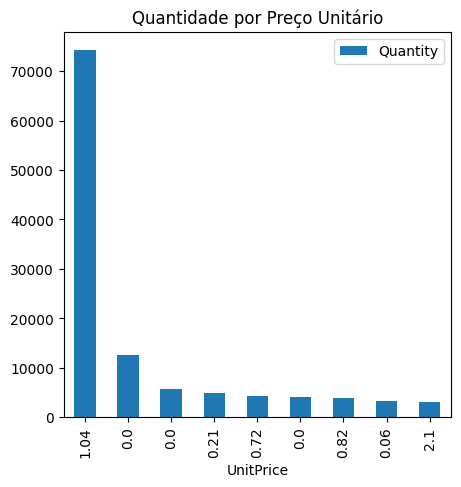

In [38]:
df.sort_values(by='Quantity', ascending=False).iloc[1:10, :].plot.bar(
    x='UnitPrice',
    y='Quantity',
    title='Quantidade por Preço Unitário',
    figsize=(5, 5),
    rot=90)

In [39]:
df['QuantityMaior'] = np.where(
    (df.Quantity>10),
    'Sim',
    'Não')

## Módulo 03

### Impacto de Outlier

In [45]:
# Exemplo de impacto de outlier na média
salarios = [1200, 1400, 1400, 1500, 1600, 1800, 2000, 2200, 2500, 50000]  # CEO incluído
s = pd.Series(salarios)

In [46]:
print(f"Média: R$ {s.mean():,.0f}")
print(f"Mediana: R$ {s.median():,.0f}")
print(f"Moda: R$ {s.mode()[0]:,.0f}")

Média: R$ 6,560
Mediana: R$ 1,700
Moda: R$ 1,400


In [47]:
s.mean()

np.float64(6560.0)

### Carregamento do Dataset - OnlineRetail

In [43]:
url_csv = "https://raw.githubusercontent.com/prof-mrafaelbatista/261_UNIESP_MBA-DADOS_data_mining_inferencia_estatistica/refs/heads/main/datasets/OnlineRetail.csv"

In [44]:
df = pd.read_csv(url_csv, encoding='latin1')

In [48]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Inspeção Básica

In [51]:
df['Quantity'].max()

np.int64(80995)

In [52]:
df['Quantity'].min()

np.int64(-80995)

In [49]:
print(df['Quantity'].mean())

9.55224954743324


In [50]:
print(df['Quantity'].median())

3.0


In [53]:
# print(df['UnitPrice'].mean())
print(f"{df['UnitPrice'].mean():.2f}")


4.61


In [54]:
print(df['UnitPrice'].median())

2.08


In [ ]:
# Classificação de variáveis
print(df.dtypes)  # object/str = categórico, int64/float64 = numérico

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


In [56]:
print(df['Country'].nunique(), "países distintos")  # variável nominal

38 países distintos
